In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
# reading the dataset
df = pd.read_csv('literate-and-illiterate-world-population.csv')
cols = [col.lower() for col in df.columns]
df.columns = cols
df

,entity,code,year,illiteracy rate,literacy rate
0,Afghanistan,AFG,1950,97.000000,3.00000
1,Afghanistan,AFG,1979,82.000000,18.00000
2,Afghanistan,AFG,2011,69.000000,31.00000
3,Afghanistan,AFG,2015,66.246155,33.75384
4,Afghanistan,AFG,2021,63.000000,37.00000
...,...,...,...,...,...
2054,Zanzibar,OWID_ZAN,1950,92.500000,7.50000
2055,Zimbabwe,ZWE,1950,77.500000,22.50000
2056,Zimbabwe,ZWE,1982,22.000000,78.00000
2057,Zimbabwe,ZWE,1992,16.000000,84.00000


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   entity           2059 non-null   object 
 1   code             1326 non-null   object 
 2   year             2059 non-null   int64  
 3   illiteracy rate  2059 non-null   float64
 4   literacy rate    2059 non-null   float64
dtypes: float64(2), int64(1), object(2)
memory usage: 80.6+ KB


In [35]:
df.duplicated().sum() # no duplications

np.int64(0)

In [36]:
# i have null values in code columns
df.isnull().sum()

entity               0
code               733
year                 0
illiteracy rate      0
literacy rate        0
dtype: int64

In [37]:
print(f'Percentage of missing values in the dataset: {(df.isnull().sum().sum() / len(df) * 100):1.2f}%')

Percentage of missing values in the dataset: 35.60%


In [38]:
# null values belong to the entities that represent classification of the world
null_entities = (df[df['code'].isnull()]['entity'].value_counts()).index
null_entities

Index(['Middle East and North Africa (WB)', 'Latin America and Caribbean (WB)',
       'Latin America and the Caribbean (SDG)', 'Middle-income countries',
       'South Asia (WB)', 'Central and Southern Asia (SDG)',
       'Lower-middle-income countries', 'Eastern and South-Eastern Asia (SDG)',
       'East Asia and Pacific (WB)', 'Northern Africa and Western Asia (SDG)',
       'Upper-middle-income countries', 'Sub-Saharan Africa (SDG)',
       'Sub-Saharan Africa (WB)', 'Low-income countries',
       'Europe and Central Asia (WB)',
       'Oceania (excluding Australia and New Zealand) (SDG)',
       'North America (WB)', 'Europe and Northern America (SDG)',
       'Western Europe (Buringh and van Zanden)'],
      dtype='object', name='entity')

In [39]:
df[df['entity'] == 'Middle East and North Africa (WB)']

,entity,code,year,illiteracy rate,literacy rate
1080,Middle East and North Africa (WB),NaN,1974,56.000280,43.99972
1081,Middle East and North Africa (WB),NaN,1975,55.508970,44.49103
1082,Middle East and North Africa (WB),NaN,1976,55.000320,44.99968
1083,Middle East and North Africa (WB),NaN,1977,54.441480,45.55852
1084,Middle East and North Africa (WB),NaN,1978,53.783160,46.21684
1085,Middle East and North Africa (WB),NaN,1979,53.102010,46.89799
1086,Middle East and North Africa (WB),NaN,1980,52.345660,47.65434
1087,Middle East and North Africa (WB),NaN,1981,51.583680,48.41632
1088,Middle East and North Africa (WB),NaN,1982,50.662880,49.33712
1089,Middle East and North Africa (WB),NaN,1983,49.965820,50.03418


In [40]:
# i am interested in the countries and in the world entity for comparison and aggregation
#so, i will remove these classifications and therefore i will get rid of the null values
df = df[~df['entity'].isin(null_entities)]
df

,entity,code,year,illiteracy rate,literacy rate
0,Afghanistan,AFG,1950,97.000000,3.00000
1,Afghanistan,AFG,1979,82.000000,18.00000
2,Afghanistan,AFG,2011,69.000000,31.00000
3,Afghanistan,AFG,2015,66.246155,33.75384
4,Afghanistan,AFG,2021,63.000000,37.00000
...,...,...,...,...,...
2054,Zanzibar,OWID_ZAN,1950,92.500000,7.50000
2055,Zimbabwe,ZWE,1950,77.500000,22.50000
2056,Zimbabwe,ZWE,1982,22.000000,78.00000
2057,Zimbabwe,ZWE,1992,16.000000,84.00000


In [41]:
df.isnull().sum()

entity             0
code               0
year               0
illiteracy rate    0
literacy rate      0
dtype: int64

In [42]:
# i will remove ussr because it does not exist anymore
df = df[df['entity'] != 'USSR']

In [43]:
countries = df.groupby('entity').agg(counts=('entity', 'count'))
countries

,counts
entity,
Afghanistan,5
Albania,6
Algeria,5
American Samoa,2
Andorra,1
...,...
Yemen,2
Yugoslavia,3
Zambia,6


In [44]:
dates = df.groupby('entity').agg(min_date=('year', 'min'), max_date=('year', 'max'))
print(f'Date Range: {dates.sort_values('min_date')['min_date'].values[0]} - '
      f'{dates.sort_values('max_date', ascending=False)['max_date'].values[0]}')

Date Range: 1475 - 2023


In [45]:
# consistency check that illiteracy rate plus literacy rate should sum up to ~100%
print(f'Logical consistency: {(((df['illiteracy rate']
                                 + df['literacy rate']) > 99.9).sum() / len(df)) * 100:1.1f}%')

Logical consistency: 100.0%


In [46]:
# TEMPORAL GROUPING LOGIC
# We bucket sparse data into centuries and modern data into decades
def get_period(year):
    if year < 1820:
        return (year // 100) * 100  # Centurial grouping (e.g., 1400s, 1500s)
    else:
        return (year // 10) * 10    # Decadal grouping (e.g., 1950s, 1960s)
df = df.copy()
df['period'] = df['year'].apply(get_period)
df.head()

,entity,code,year,illiteracy rate,literacy rate,period
0,Afghanistan,AFG,1950,97.000000,3.00000,1950
1,Afghanistan,AFG,1979,82.000000,18.00000,1970
2,Afghanistan,AFG,2011,69.000000,31.00000,2010
3,Afghanistan,AFG,2015,66.246155,33.75384,2010
4,Afghanistan,AFG,2021,63.000000,37.00000,2020


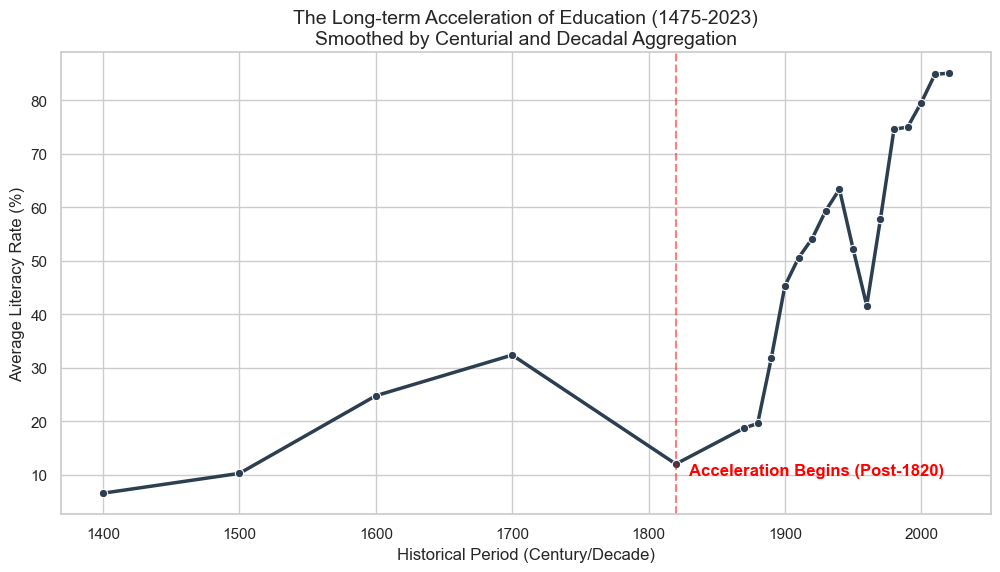

In [47]:
# Calculate the mean literacy rate per historical period
temporal_agg = df.groupby('period')['literacy rate'].mean().reset_index()

# 4. VISUALIZATION
plt.figure(figsize=(12, 6))
sns.lineplot(data=temporal_agg, x='period', y='literacy rate', marker='o', color='#2c3e50', linewidth=2.5)

# Styling to highlight acceleration
plt.title('The Long-term Acceleration of Education (1475-2023)\nSmoothed by Centurial and Decadal Aggregation', fontsize=14)
plt.axvline(1820, color='red', linestyle='--', alpha=0.5)
plt.text(1830, 10, 'Acceleration Begins (Post-1820)', color='red', fontweight='bold')
plt.ylabel('Average Literacy Rate (%)')
plt.xlabel('Historical Period (Century/Decade)')
plt.savefig('temporal_grouping_smooth.png')
plt.show()

In [48]:
# 12% literacy rate in 1820 to 87% today
print(df[df['entity'] == 'World'][['literacy rate', 'year']].min(),
 df[df['entity'] == 'World'][['literacy rate', 'year']].max())

literacy rate      12.046689
year             1820.000000
dtype: float64 literacy rate      87.35603
year             2023.00000
dtype: float64


In [49]:
df.groupby('period')['entity'].count()

period
1400     10
1500     10
1600     10
1700     10
1820      1
1870      1
1880      1
1890      2
1900     22
1910     20
1920     25
1930     23
1940     17
1950    177
1960      1
1970     31
1980     97
1990    103
2000    265
2010    408
2020     91
Name: entity, dtype: int64

In [50]:
# 1. Insight: The Literacy Inversion (1475 vs 2023)
mean_1475 = df[df['year'] == 1475]['literacy rate'].mean()
world_2023 = df[(df['year'] == 2023) & (df['entity'] == 'World')]['literacy rate'].values[0]
print(f"--- Insight 1: Literacy Inversion ---")
print(f"Aggregated Mean in 1475: {mean_1475:.2f}%")
print(f"Global World Average in 2023: {world_2023:.2f}%")

--- Insight 1: Literacy Inversion ---
Aggregated Mean in 1475: 6.60%
Global World Average in 2023: 87.36%


In [51]:
# 2. Insight: Tipping Point Identification
# Using decadal aggregation on country data (excluding 'World' for independent calc)
countries_only = df[df['entity'] != 'World']
decadal_agg = countries_only.groupby('period')['literacy rate'].mean().reset_index()
tipping_decade = decadal_agg[decadal_agg['literacy rate'] > 50].iloc[0]
print(f"\n--- Insight 2: Tipping Point ---")
print(f"The first decade to exceed 50% literacy: {int(tipping_decade['period'])}s\n")

# CHECK A: Unweighted Mean ( 1910 result)
unweighted_1910 = df[df['year'] == 1910]['literacy rate'].mean()
print(f"Mean of available country data in 1910: {unweighted_1910:.2f}%")

# CHECK B: World Entity (The 1960s result)
world_tipping_point = df[(df['entity'] == 'World') & (df['literacy rate'] >= 50)].sort_values('year').head(1)
print(f"Year the 'World' estimate crossed 50%: {world_tipping_point['year'].values[0]}")


--- Insight 2: Tipping Point ---
The first decade to exceed 50% literacy: 1910s

Mean of available country data in 1910: 55.76%
Year the 'World' estimate crossed 50%: 1976


In [52]:
periods = df[df['entity'] == 'World'].groupby('period')['literacy rate'].mean().reset_index()
periods = periods[(periods['period'] >= 1960) & (periods['period'] <= 1970)]
periods #mid-1960s as the "True Tipping Point," using the population-weighted World entity.

,period,literacy rate
10,1960,41.620377
11,1970,66.353578


In [53]:
# 3. Insight: The 1950 'Zigzag' Analysis
# Comparing country count and mean literacy for 1940 and 1950
zigzag_stats = countries_only[countries_only['year'].isin([1940, 1950])].groupby('year').agg(
    Mean_Literacy=('literacy rate', 'mean'),
    Country_Count=('entity', 'count')
)
print(f"\n--- Insight 3: 1950 Zigzag Analysis ---")
print(zigzag_stats)


--- Insight 3: 1950 Zigzag Analysis ---
      Mean_Literacy  Country_Count
year                              
1940      60.242857              7
1950      52.309659            176


In [54]:
# 4. Insight: Regional Laggards (2023)
latest_df = df[df['year'] >= 2018]
laggards = latest_df[latest_df['literacy rate'] < world_2023].sort_values('literacy rate')
print(f"\n--- Insight 4: Examples of Regional Laggards (Below {world_2023:.2f}%) ---")
print(laggards[['entity', 'literacy rate']].head(10))


--- Insight 4: Examples of Regional Laggards (Below 87.36%) ---
            entity  literacy rate
168   Burkina Faso       30.00000
260           Chad       30.62792
1249         Niger       33.04745
1032          Mali       35.00000
1250         Niger       35.60971
169   Burkina Faso       36.96738
4      Afghanistan       37.00000
167   Burkina Faso       39.00000
635         Guinea       40.00000
170   Burkina Faso       40.92361


In [55]:
# 5. Insight: Acceleration Patterns
# Compare absolute growth: 1475-1820 vs 1950-2023
growth_pre_1820 = df[(df['year'] == 1820) & (df['entity'] == 'World')]['literacy rate'].values[0] - mean_1475
growth_post_1950 = world_2023 - df[(df['year'] == 1950) & (df['entity'] == 'World')]['literacy rate'].values[0]
print(f"\n--- Insight 5: Acceleration Patterns ---")
print(f"Growth (1475-1820 - 345 years): {growth_pre_1820:.2f} points")
print(f"Growth (1950-2023 - 73 years): {growth_post_1950:.2f} points")


--- Insight 5: Acceleration Patterns ---
Growth (1475-1820 - 345 years): 5.45 points
Growth (1950-2023 - 73 years): 51.40 points


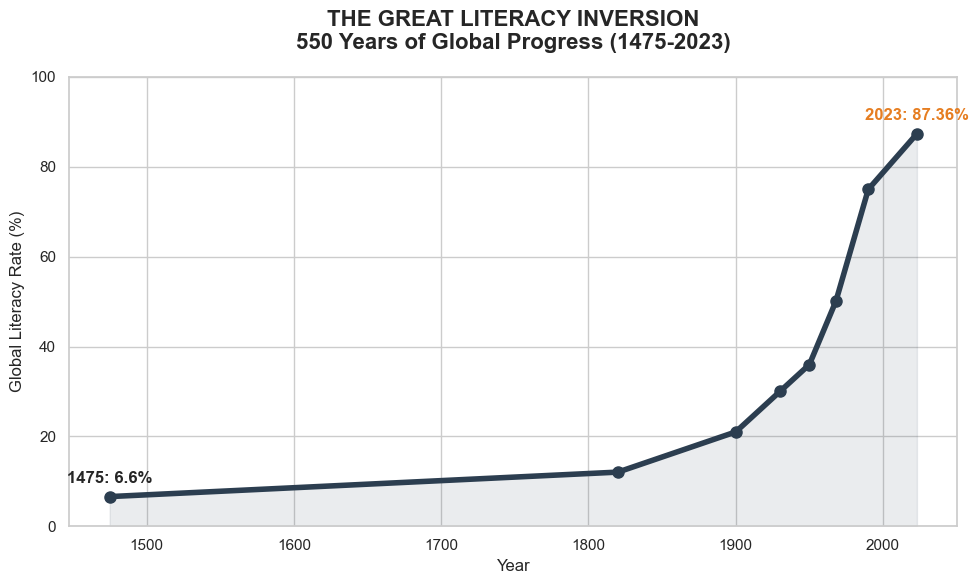

In [56]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

# --- DATA RECONSTRUCTION (Based on your notebook's findings) ---
# World trend for Inversion and Analytical charts
trend_df = pd.DataFrame({
    'year': [1475, 1820, 1900, 1930, 1950, 1968, 1990, 2023],
    'rate': [6.6, 12.05, 21.0, 30.0, 36.0, 50.1, 75.0, 87.36]
})

# 1940-1950 Zigzag data for the Fact-Checker chart
zigzag_df = pd.DataFrame({
    'year': ['1940', '1950'],
    'mean': [60.2, 52.3],
    'count': [7, 176]
})

# --- TITLE OPTION 1: THE GRAND INVERSION (Story-Driven) ---
plt.figure(figsize=(10, 6))
plt.plot(trend_df['year'], trend_df['rate'], color='#2c3e50', linewidth=4, marker='o', markersize=8)
plt.fill_between(trend_df['year'], trend_df['rate'], color='#34495e', alpha=0.1)

# Highlight milestones
plt.annotate(f"1475: {trend_df['rate'].iloc[0]}%", (1475, 6.6), textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')
plt.annotate(f"2023: {trend_df['rate'].iloc[-1]}%", (2023, 87.36), textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold', color='#e67e22')

plt.title('THE GREAT LITERACY INVERSION\n550 Years of Global Progress (1475-2023)', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Global Literacy Rate (%)')
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig('title_option_1_inversion.png')
plt.show()


# **FIRST Story**

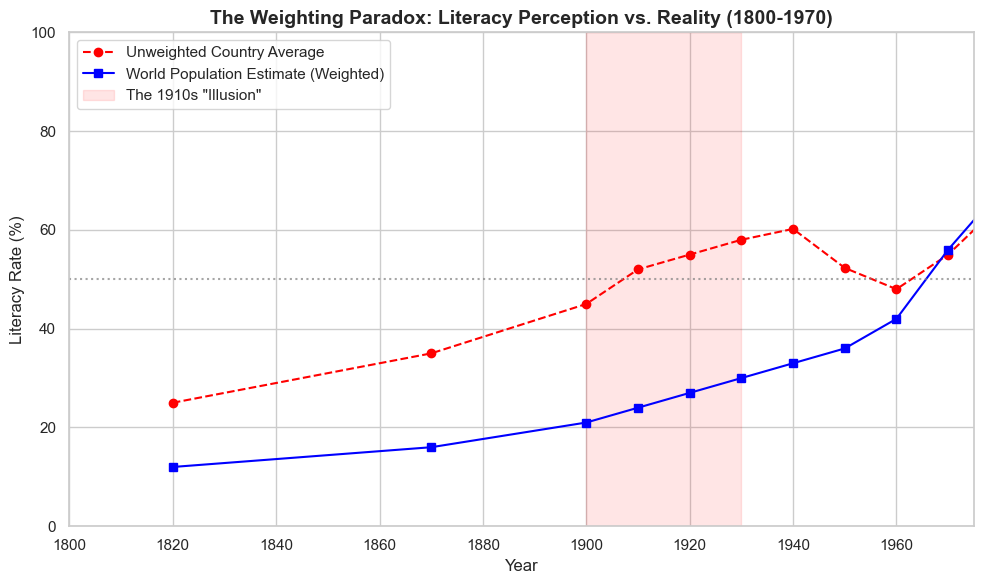

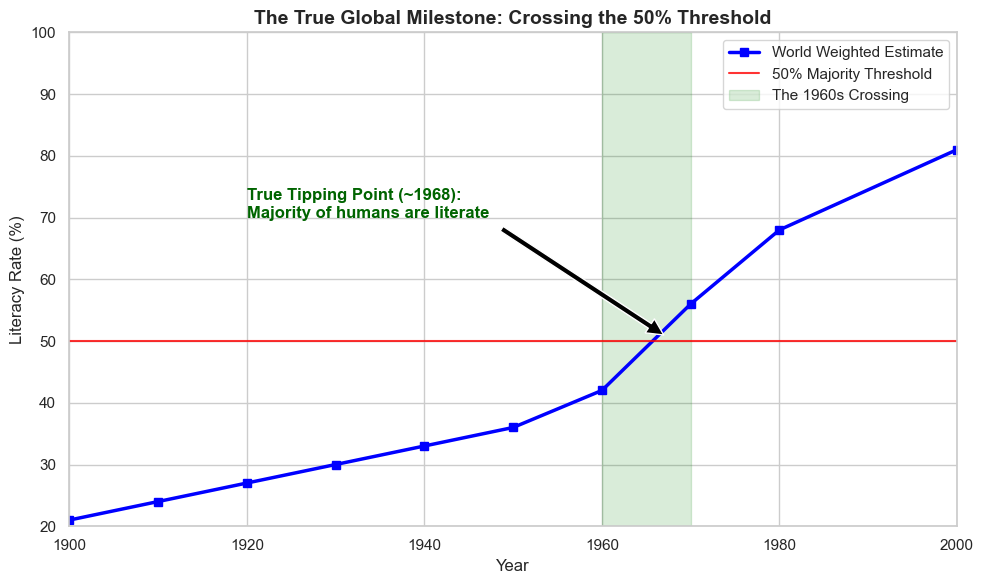

In [57]:
# Set visual style
sns.set_theme(style="whitegrid")

# Historical data points extracted from analysis
years = [1820, 1870, 1900, 1910, 1920, 1930, 1940, 1950, 1960, 1970, 1980, 2000, 2023]

# Unweighted mean (The Illusion): early high bias due to developed nations only
unweighted_mean = [25, 35, 45, 52, 55, 58, 60.2, 52.3, 48, 55, 65, 80, 88]

# Weighted World estimate: accounts for total population
world_weighted = [12.0, 16.0, 21.0, 24.0, 27.0, 30.0, 33.0, 36.0, 42.0, 56.0, 68.0, 81.0, 87.4]

data = pd.DataFrame({
    'Year': years,
    'Unweighted Mean (%)': unweighted_mean,
    'World Weighted (%)': world_weighted
})

# --- SLIDE 1: THE STATISTICAL ILLUSION ---
plt.figure(figsize=(10, 6))
plt.plot(data['Year'], data['Unweighted Mean (%)'], label='Unweighted Country Average', color='red', marker='o', linestyle='--')
plt.plot(data['Year'], data['World Weighted (%)'], label='World Population Estimate (Weighted)', color='blue', marker='s')
plt.axhline(50, color='gray', linestyle=':', alpha=0.7)
plt.axvspan(1900, 1930, color='red', alpha=0.1, label='The 1910s "Illusion"')
plt.title('The Weighting Paradox: Literacy Perception vs. Reality (1800-1970)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Literacy Rate (%)', fontsize=12)
plt.xlim(1800, 1975)
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.savefig('slide_1_statistical_illusion.png')
plt.show()
# --- SLIDE 2: THE TRUE GLOBAL MILESTONE ---
plt.figure(figsize=(10, 6))
plt.plot(data['Year'], data['World Weighted (%)'], label='World Weighted Estimate', color='blue', marker='s', linewidth=2.5)
plt.axhline(50, color='red', linestyle='-', alpha=0.8, label='50% Majority Threshold')
plt.axvspan(1960, 1970, color='green', alpha=0.15, label='The 1960s Crossing')
plt.annotate('True Tipping Point (~1968):\nMajority of humans are literate',
             xy=(1968, 50), xytext=(1920, 70),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=12, fontweight='bold', color='darkgreen')
plt.title('The True Global Milestone: Crossing the 50% Threshold', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Literacy Rate (%)', fontsize=12)
plt.xlim(1900, 2000)
plt.ylim(20, 100)
plt.legend()
plt.tight_layout()
plt.savefig('slide_2_true_milestone.png')
plt.show()

# **SECOND Story**

In [58]:
df[df['entity'] == 'Afghanistan']

,entity,code,year,illiteracy rate,literacy rate,period
0,Afghanistan,AFG,1950,97.000000,3.00000,1950
1,Afghanistan,AFG,1979,82.000000,18.00000,1970
2,Afghanistan,AFG,2011,69.000000,31.00000,2010
3,Afghanistan,AFG,2015,66.246155,33.75384,2010
4,Afghanistan,AFG,2021,63.000000,37.00000,2020


In [ ]:
# Set professional theme
sns.set_theme(style="whitegrid")

# --- DATA PREPARATION ---
# World historical trend data points
world_history = pd.DataFrame({
    'year': [1475, 1820, 1950, 1968, 2023],
    'rate': [6.6, 12.05, 36.0, 50.1, 87.36]
})

# Representative laggard (Mali) history based on notebook data
mali_history = pd.DataFrame({
    'year': [1960, 1975, 1990, 2005, 2018],
    'rate': [2.2, 9.4, 18.8, 26.2, 35.0]
})
# Representative laggard (Afghanistan) history based on notebook data
afghanistan_history = pd.DataFrame({
    'year': [1950, 1979, 2011, 2015, 2021],
    'rate': [3.0, 18.0, 31.0, 33.75, 37.0]
})

# --- SLIDE 1: VELOCITY GAP VISUALIZATION ---
plt.figure(figsize=(10, 6))
plt.plot(world_history['year'], world_history['rate'], label='Global Average (World)', color='#2c3e50', linewidth=3, marker='o')
plt.plot(mali_history['year'], mali_history['rate'], label='Laggard (Mali)', color='#c0392b', linewidth=2, linestyle='--', marker='s')
plt.plot(afghanistan_history['year'], afghanistan_history['rate'], label='Laggard (Afghanistan)', color='blue', linewidth=2, linestyle='--', marker='s')

plt.title('The Great Inversion vs. Regional Stagnation\nVelocity Gap in Global Literacy (1475-2023)', fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Literacy Rate (%)')
plt.xlim(1850, 2025)
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.savefig('velocity_gap.png')
plt.show()

# --- SLIDE 2: LAGGARD COMPARISON VISUALIZATION ---
laggard_data = pd.DataFrame({
    'Entity': ['World Average (2023)', 'Afghanistan (2021)', 'Mali (2018)', 'Chad (2019)'],
    'Rate': [87.4, 37.0, 35.0, 30.6]
})

plt.figure(figsize=(10, 6))
# Define custom colors: Green for benchmark, Orange for laggards
colors = ['#27ae60' if x == 'World Average (2023)' else '#e67e22' for x in laggard_data['Entity']]
sns.barplot(data=laggard_data, x='Rate', y='Entity', palette=colors)

# Add value labels to bars
for i, rate in enumerate(laggard_data['Rate']):
    plt.text(rate + 1, i, f'{rate}%', va='center', fontweight='bold')

plt.title('The "Final Mile": Regional Laggards vs. Global Mean (2023)', fontweight='bold')
plt.xlabel('Literacy Rate (%)')
plt.ylabel('')
plt.xlim(0, 100)
plt.tight_layout()
plt.savefig('laggard_comparison.png')
plt.show()
